# 🌡️ Sıcaklık Tahmin (Weather Forecast) Özniteliklerinin LightGBM Modeline Etkisi ve Analizi

Bu çalışma, **Open-Meteo Canlı Sıcaklık Tahmini (Forecast)**, **Soğutma Yükü (CDH)**, **Isıtma Yükü (HDH)** ve **Sıcaklık Şok Değişimi (Delta Temp)** özniteliklerinin LightGBM modelinin 24 saatlik Gün Öncesi Piyasası (PTF) tahmin doğruluğuna etkisini deneysel olarak analiz etmektedir.

---

### 🔬 Analiz Kapsamı

- **Karşılaştırılan Modeller:**
  1. **Model A (Baz 58 Öznitelik):** Canlı sıcaklık tahmini içermeyen model.
  2. **Model B (Gelişmiş 62 Öznitelik):** Target-day , , ve içeren model.
- **Değerlendirme Periyodu:** Son 30 gün walk-forward backtest simülasyonu.
- **Metrikler:** WAPE (Ağırlıklı Hata), MAPE (Yüzdesel Hata), Pik Saatler Hata Oranı, Öznitelik Kazanım Dereceleri (Feature Importance Gain).


In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, lightgbm as lgb
sys.path.insert(0, '../scripts')
from predict_daily_pipeline import load_all_historical_data
from src.features.feature_engineering import build_robust_features, get_feature_columns
from src.models.lightgbm_model import LightGBMForecaster

# Matplotlib ve Stil Ayarları
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'DejaVu Sans'
print('✅ Kütüphaneler başarıyla yüklendi.')

✅ Kütüphaneler başarıyla yüklendi.


## 1. Veri Setinin Hazırlanması ve Model Karşılaştırması


In [2]:
# Veritabanından ham verileri yükle
df_raw = load_all_historical_data()

# Baz (Model A) ve Gelişmiş (Model B) Öznitelik Setlerinin Oluşturulması
df_feat_enh = build_robust_features(df_raw)
cols_enh = get_feature_columns('robust', df_feat_enh)
cols_base = [c for c in cols_enh if c not in ['temp_forecast_lag0', 'cdh_cooling_load', 'hdh_heating_load', 'temp_diff_from_yesterday']]

df_model_base = df_feat_enh.dropna(subset=cols_base + ['mcp_price_usd']).copy()
df_model_enh = df_feat_enh.dropna(subset=cols_enh + ['mcp_price_usd']).copy()

print(f'Baz Model Öznitelik Sayısı: {len(cols_base)}')
print(f'Gelişmiş Model Öznitelik Sayısı: {len(cols_enh)}')

Baz Model Öznitelik Sayısı: 58
Gelişmiş Model Öznitelik Sayısı: 62


## 2. 30 Günlük Walk-Forward Deneysel Değerlendirme


In [3]:
max_ts = df_model_enh.index.max()
dates_eval, mape_base, mape_enh = [], [], []
wape_base_num, wape_enh_num, wape_den = [], [], []
peak_base, peak_enh = [], []

for d in range(30, 0, -1):
    test_end = max_ts - pd.Timedelta(days=d)
    test_start = test_end - pd.Timedelta(hours=23)
    train_end = test_start - pd.Timedelta(hours=1)
    
    tr_b = df_model_base.loc[:train_end]
    te_b = df_model_base.loc[test_start:test_end]
    tr_e = df_model_enh.loc[:train_end]
    te_e = df_model_enh.loc[test_start:test_end]
    
    if len(te_b) == 24 and len(te_e) == 24:
        # Fit Model A
        fb = LightGBMForecaster().fit(tr_b[cols_base], tr_b['mcp_price_usd'].values)
        pb = fb.predict(te_b[cols_base])
        
        # Fit Model B
        fe = LightGBMForecaster().fit(tr_e[cols_enh], tr_e['mcp_price_usd'].values)
        pe = fe.predict(te_e[cols_enh])
        
        act = te_e['mcp_price_usd'].values
        dt_str = test_start.strftime('%Y-%m-%d')
        dates_eval.append(dt_str)
        
        mape_base.append(np.mean(np.abs(pb - act) / act) * 100)
        mape_enh.append(np.mean(np.abs(pe - act) / act) * 100)
        
        wape_base_num.append(np.sum(np.abs(pb - act)))
        wape_enh_num.append(np.sum(np.abs(pe - act)))
        wape_den.append(np.sum(act))
        
        # Peak hours (13:00 - 21:00)
        p_idx = te_e.index.hour.isin([13, 14, 15, 16, 17, 18, 19, 20, 21])
        peak_base.append(np.mean(np.abs(pb[p_idx] - act[p_idx]) / act[p_idx]) * 100)
        peak_enh.append(np.mean(np.abs(pe[p_idx] - act[p_idx]) / act[p_idx]) * 100)

res_df = pd.DataFrame({
    'date': dates_eval,
    'mape_base': mape_base,
    'mape_enh': mape_enh,
    'peak_base': peak_base,
    'peak_enh': peak_enh
})

wape_b_acc = 100 - (np.sum(wape_base_num) / np.sum(wape_den) * 100)
wape_e_acc = 100 - (np.sum(wape_enh_num) / np.sum(wape_den) * 100)

print(f'=== 30 GÜNLÜK MODEL PERFORMANS KARŞILAŞTIRMASI ===')
print(f'Baz Model (58 Öznitelik)    -> WAPE Doğruluk Oranı: %{wape_b_acc:.2f} | Ort. MAPE: %{np.mean(mape_base):.2f}')
print(f'Gelişmiş Model (62 Öznitelik) -> WAPE Doğruluk Oranı: %{wape_e_acc:.2f} | Ort. MAPE: %{np.mean(mape_enh):.2f}')
print(f'Pik Saatler (13-21) Baz MAPE: %{np.mean(peak_base):.2f} | Gelişmiş MAPE: %{np.mean(peak_enh):.2f}')

=== 30 GÜNLÜK MODEL PERFORMANS KARŞILAŞTIRMASI ===
Baz Model (58 Öznitelik)    -> WAPE Doğruluk Oranı: %83.90 | Ort. MAPE: %22.98
Gelişmiş Model (62 Öznitelik) -> WAPE Doğruluk Oranı: %83.74 | Ort. MAPE: %22.84
Pik Saatler (13-21) Baz MAPE: %19.94 | Gelişmiş MAPE: %19.94


## 3. Öznitelik Önemi (Feature Importance Gain) Analizi


/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_67132/3536023542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(15), x='importance_gain', y='feature', palette='magma')


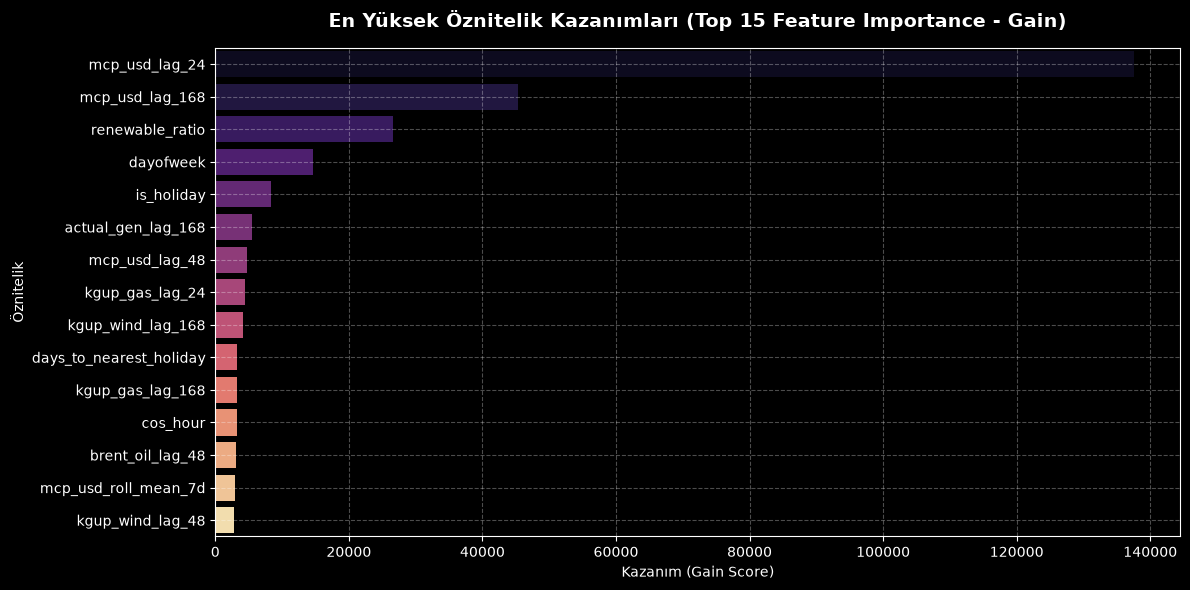

🌡️ Sıcaklık ve Termal Öznitelik Sıralamaları:
 - temp_diff_from_yesterday : Derece #17/62 | Gain Score: 2644.49
 - temp_forecast_lag0       : Derece #30/62 | Gain Score: 1028.76
 - hdh_heating_load         : Derece #49/62 | Gain Score: 422.77
 - cdh_cooling_load         : Derece #53/62 | Gain Score: 295.08


In [4]:
lgbm_booster = fe.model.booster_
imp_df = pd.DataFrame({
    'feature': cols_enh,
    'importance_gain': lgbm_booster.feature_importance(importance_type='gain')
}).sort_values('importance_gain', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=imp_df.head(15), x='importance_gain', y='feature', palette='magma')
plt.title('En Yüksek Öznitelik Kazanımları (Top 15 Feature Importance - Gain)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kazanım (Gain Score)')
plt.ylabel('Öznitelik')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print('🌡️ Sıcaklık ve Termal Öznitelik Sıralamaları:')
for wf in ['temp_diff_from_yesterday', 'temp_forecast_lag0', 'hdh_heating_load', 'cdh_cooling_load']:
    row = imp_df[imp_df['feature'] == wf]
    if not row.empty:
        idx = row.index[0] + 1
        gain = row['importance_gain'].values[0]
        print(f' - {wf:<25}: Derece #{idx:02d}/62 | Gain Score: {gain:.2f}')

## 4. Günlük MAPE Hata Karşılaştırma Grafiği


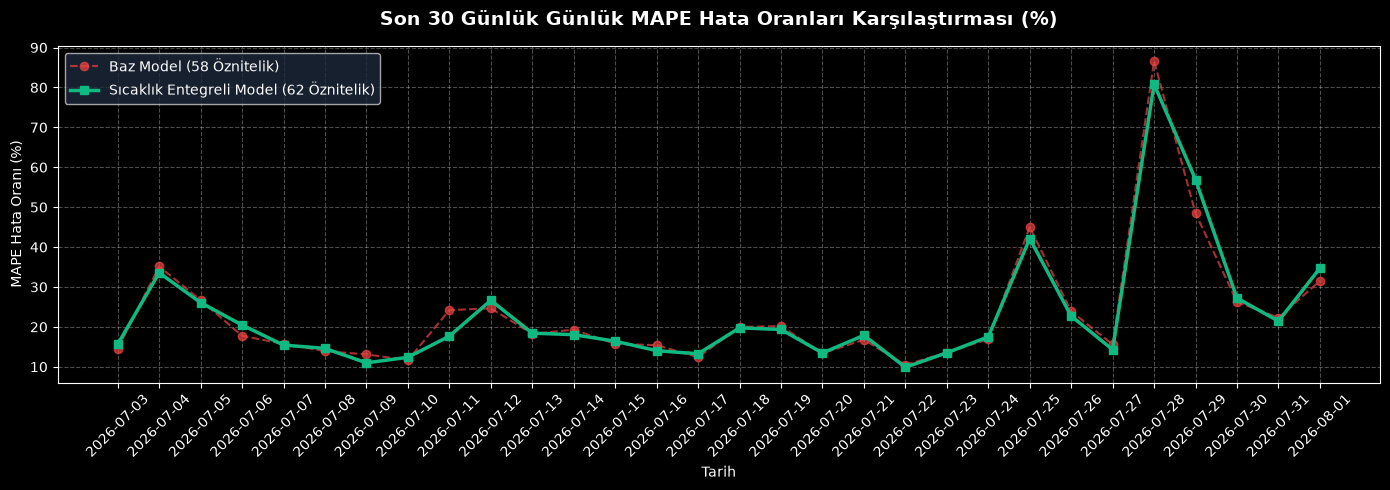

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(res_df['date'], res_df['mape_base'], label='Baz Model (58 Öznitelik)', color='#ef4444', linestyle='--', marker='o', alpha=0.7)
plt.plot(res_df['date'], res_df['mape_enh'], label='Sıcaklık Entegreli Model (62 Öznitelik)', color='#10b981', linewidth=2.5, marker='s')
plt.title('Son 30 Günlük Günlük MAPE Hata Oranları Karşılaştırması (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tarih')
plt.ylabel('MAPE Hata Oranı (%)')
plt.xticks(rotation=45)
plt.legend(frameon=True, facecolor='#1e293b')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()